In [ ]:
from google.colab import auth
import gspread
from google.auth import default
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

auth.authenticate_user()
creds, _ = default()
gc = gspread.authorize(creds)

file_id = '11vJXajjCLX1-LJeQ3FXsCo_yr-zZv49mnHq-6MDlhqw'
sh = gc.open_by_key(file_id)
worksheet = sh.worksheet('5A')

datos = worksheet.get('A1:E23')
df = pd.DataFrame(datos[1:], columns=datos[0])
print(df.head())

  No.  Matrícula           Nombre del Estudiante Altura (cm) Peso (KG)
0   1  243112024         ARTEAGA CASTILLO ISRAEL         189       104
1   2  243110670     AVILA ENCISO GUILLERMO JOSE         176        90
2   3  243111514         AVILA JUAREZ JOSE ANGEL         182       110
3   4  243110528           AVILA VAZQUEZ ARMANDO         172        87
4   5  243111280  CERON TRUJILLO XAVIER APOLINAR         170        63


In [ ]:
#Calcular parametros de r
x = pd.to_numeric(df['Altura (cm)'], errors='coerce')
y = pd.to_numeric(df['Peso (KG)'], errors='coerce')

n = len(x)
sum_x   = x.sum()
sum_y   = y.sum()
sum_xy  = (x * y).sum()
sum_x2  = (x ** 2).sum()
sum_y2  = (y ** 2).sum()

r = (n * sum_xy - sum_x * sum_y) / \
    np.sqrt((n * sum_x2 - sum_x**2) * (n * sum_y2 - sum_y**2))

print(f"r = {r:.4f}")

r = 0.8182


In [ ]:
#Calcular los parametros de x,y, media de x, media de y, desviacion de x, desviacion de y
media_x = x.mean()
media_y = y.mean()
std_x   = x.std()
std_y   = y.std()

print(f"Media X (Altura): {media_x:.4f}")
print(f"Media Y (Peso):   {media_y:.4f}")
print(f"Desv. Est. X:     {std_x:.4f}")
print(f"Desv. Est. Y:     {std_y:.4f}")

Media X (Altura): 169.1364
Media Y (Peso):   70.1364
Desv. Est. X:     8.3226
Desv. Est. Y:     18.9819


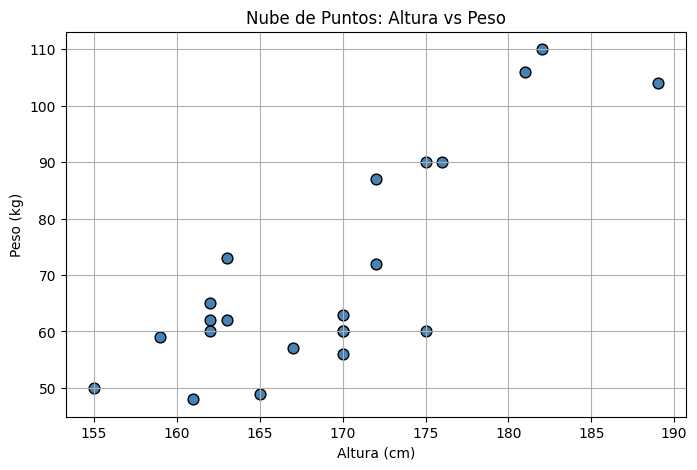

In [ ]:
#Graficar la nube de puntos
plt.figure(figsize=(8, 5))
plt.scatter(x, y, color='steelblue', edgecolors='black', s=60)
plt.xlabel('Altura (cm)')
plt.ylabel('Peso (kg)')
plt.title('Nube de Puntos: Altura vs Peso')
plt.grid(True)
plt.show()

In [ ]:
#Calcular los coeficientes de m y b (la recta)
m = (n * sum_xy - sum_x * sum_y) / (n * sum_x2 - sum_x**2)
b = (sum_y - m * sum_x) / n

print(f"Pendiente m = {m:.4f}")
print(f"Intercepto b = {b:.4f}")
print(f"Recta: y = {m:.4f}x + ({b:.4f})")

Pendiente m = 1.8662
Intercepto b = -245.5098
Recta: y = 1.8662x + (-245.5098)


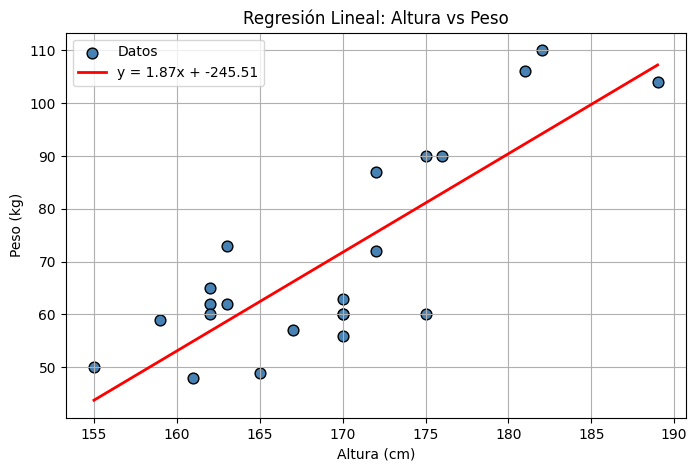

In [ ]:
#Graficar la nube mas la recta
x_linea = np.linspace(x.min(), x.max(), 100)
y_linea = m * x_linea + b

plt.figure(figsize=(8, 5))
plt.scatter(x, y, color='steelblue', edgecolors='black', s=60, label='Datos')
plt.plot(x_linea, y_linea, color='red', linewidth=2, label=f'y = {m:.2f}x + {b:.2f}')
plt.xlabel('Altura (cm)')
plt.ylabel('Peso (kg)')
plt.title('Regresión Lineal: Altura vs Peso')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
#Hacer una prediccion con 175cm
altura_pred = 175
peso_pred = m * altura_pred + b

print(f"Para una altura de {altura_pred} cm:")
print(f"Peso estimado = {peso_pred:.2f} kg")

Para una altura de 175 cm:
Peso estimado = 81.08 kg


Pendiente  m = 1.8662
Intercepto b = -245.5098
Ecuación:  y = 1.8662x + (-245.5098)
Coef. correlación r = 0.8182
Error estándar Se = 11.1816 kg


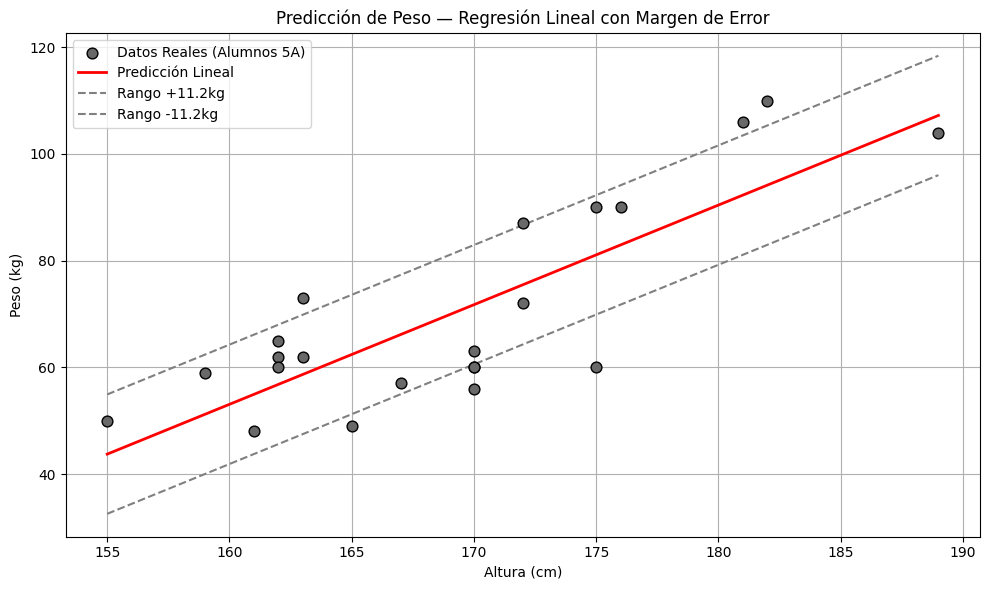

In [ ]:
# Calculo de la linea de regresion lineal y margenes de error
from scipy import stats

m = (n * sum_xy - sum_x * sum_y) / (n * sum_x2 - sum_x**2)
b = (sum_y - m * sum_x) / n

# Error estándar de estimación (Se)
y_pred = m * x + b
Se = np.sqrt(((y - y_pred)**2).sum() / (n - 2))

print(f"Pendiente  m = {m:.4f}")
print(f"Intercepto b = {b:.4f}")
print(f"Ecuación:  y = {m:.4f}x + ({b:.4f})")
print(f"Coef. correlación r = {r:.4f}")
print(f"Error estándar Se = {Se:.4f} kg")

# Línea de regresión y márgenes ±Se
x_linea = np.linspace(x.min(), x.max(), 100)
y_linea = m * x_linea + b

# Gráfica
plt.figure(figsize=(10, 6))
plt.scatter(x, y, color='dimgray', edgecolors='black', s=60, label='Datos Reales (Alumnos 5A)', zorder=5)
plt.plot(x_linea, y_linea,        color='red',  linewidth=2,   linestyle='-',  label='Predicción Lineal')
plt.plot(x_linea, y_linea + Se,   color='gray', linewidth=1.5, linestyle='--', label=f'Rango +{Se:.1f}kg')
plt.plot(x_linea, y_linea - Se,   color='gray', linewidth=1.5, linestyle='--', label=f'Rango -{Se:.1f}kg')
plt.xlabel('Altura (cm)')
plt.ylabel('Peso (kg)')
plt.title('Predicción de Peso — Regresión Lineal con Margen de Error')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()